# Part 1 - Business Understanding & Data Cleaning

# Singapore Job Market Intelligence Dashboard

---

## Executive Summary

### Business Problem

Job seekers often rely on individual job postings without having a comprehensive view of the Singapore job market. This makes it difficult to compare industries based on:

- 💰 Salary
- 📈 Hiring Demand
- 👥 Competition
- 📅 Market Trends

This notebook focuses on understanding and preparing the dataset before any analysis or dashboard development.

---

## Workflow

1. Business Understanding
2. Data Understanding
3. Data Quality Assessment
4. Data Cleaning
5. Feature Engineering
6. Clean Dataset Validation


# 1. Business Understanding

## Target Users
- Job Seekers
- Career Advisors
- Workforce Planners

## Project Objective

Build a data product that provides insights into Singapore's job market using historical job postings.

## Business Questions

1. Which industries pay the highest salaries?
2. Which industries have the greatest hiring demand?
3. Which industries receive the most applications?
4. Which industries are hardest to fill?
5. How has hiring changed over time?

> These questions will drive all analysis performed later.


# 2. Data Understanding

Before cleaning data we first understand:

- Dataset size
- Data types
- Missing values
- Data quality
- Relationships between variables

Understanding the data helps us choose the appropriate cleaning techniques.


In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [132]:
from pathlib import Path

# Load dataset
possible_paths = [
    Path("notebooks/SGJobData.csv"),
    Path("SGJobData.csv"),
    Path("data/SGJobData.csv"),
    Path("../notebooks/SGJobData.csv"),
    Path("../data/SGJobData.csv"),
]

csv_path = next((p for p in possible_paths if p.is_file()), None)
if csv_path is None:
    raise FileNotFoundError(
        "SGJobData.csv not found. Checked paths: " + ", ".join(str(p) for p in possible_paths)
    )

df = pd.read_csv(csv_path)
print("Rows, Columns:", df.shape)



Rows, Columns: (1048585, 22)


In [133]:
# Display column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048585 entries, 0 to 1048584
Data columns (total 22 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   categories                          1044597 non-null  object 
 1   employmentTypes                     1044597 non-null  object 
 2   metadata_expiryDate                 1044597 non-null  object 
 3   metadata_isPostedOnBehalf           1048585 non-null  bool   
 4   metadata_jobPostId                  1044597 non-null  object 
 5   metadata_newPostingDate             1044597 non-null  object 
 6   metadata_originalPostingDate        1044597 non-null  object 
 7   metadata_repostCount                1048585 non-null  int64  
 8   metadata_totalNumberJobApplication  1048585 non-null  int64  
 9   metadata_totalNumberOfView          1048585 non-null  int64  
 10  minimumYearsExperience              1048585 non-null  int64  
 11  numberOfVac

In [134]:
df.shape

(1048585, 22)

## Understanding the Columns

|Category|Examples|
|---|---|
|Identifiers|Job Post ID|
|Categorical|Industry, Employment Type, Position Level|
|Numerical|Salary, Vacancies, Applications, Views|
|Date|Posting Date, Repost Date, Expiry Date|

Knowing the column types helps determine the correct cleaning strategy.


# 3. Data Quality Assessment

Good dashboards require high-quality data.

We will examine:

- Duplicate records
- Missing values
- Invalid values
- Incorrect data types
- Data consistency

Each issue is evaluated before deciding whether data should be cleaned, removed or retained.


## 3.1 Duplicate Records

In [135]:
duplicates=df.duplicated().sum()
print(f"Duplicate Records: {duplicates}")

if duplicates>0:
    print("Recommendation: Remove duplicate rows before analysis.")
else:
    print("No duplicate rows found.")


Duplicate Records: 3987
Recommendation: Remove duplicate rows before analysis.


### Why does this matter?

Duplicate records can artificially increase:

- Job counts
- Vacancy counts
- Salary averages
- Hiring demand

Removing duplicates improves the reliability of business insights.


## 3.2 Missing Value Assessment

In [136]:
missing=pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing %':(df.isnull().mean()*100).round(2)
}).sort_values('Missing %',ascending=False)

display(missing)


,Missing Count,Missing %
occupationId,1048585,100.00
categories,3988,0.38
metadata_expiryDate,3988,0.38
metadata_jobPostId,3988,0.38
metadata_newPostingDate,3988,0.38
employmentTypes,3988,0.38
status_jobStatus,3988,0.38
metadata_originalPostingDate,3988,0.38
positionLevels,3988,0.38
postedCompany_name,3988,0.38


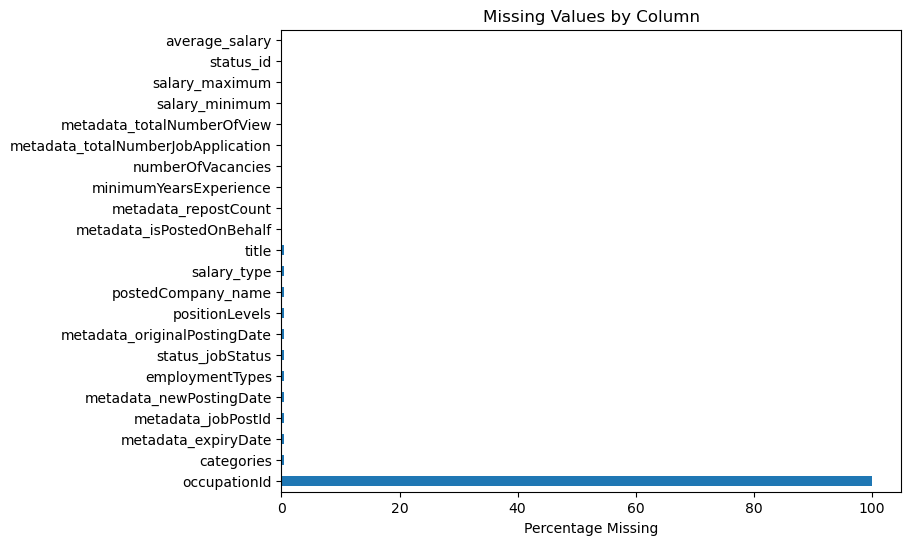

In [137]:
# Visualise missing values
missing['Missing %'].plot(kind='barh', figsize=(8,6))
plt.title('Missing Values by Column')
plt.xlabel('Percentage Missing')
plt.show()


### Interpretation

After plotting the missing values:

Ask yourself:

- Which columns have the highest percentage of missing values?
- Are these columns important for answering the business questions?
- Can they be imputed or should they remain missing?


## 3.3 Missing Value Strategy

|Column|Business Importance|Recommended Action|Reason|
|---|---|---|---|
|salary_minimum|High|Median|Numeric, robust against outliers|
|salary_maximum|High|Median|Numeric|
|average_salary|High|Recalculate|Derived field|
|minimumYearsExperience|Medium|Median|Typical numeric field|
|positionLevels|Medium|Fill 'Unknown'|Preserve records|
|employmentTypes|Medium|Fill 'Unknown'|Preserve records|
|Applications|High|Do NOT Impute|Missing ≠ Zero|
|Views|Medium|Do NOT Impute|Cannot estimate accurately|
|Vacancies|High|Do NOT Impute|Guessing changes hiring demand|
|Categories|Very High|Drop if missing|Industry analysis depends on it|
|Posting Dates|Very High|Drop if missing|Essential for trend analysis|


### Why Some Columns Should NOT Be Imputed

Suppose Applications is missing.

Does that mean:

- Zero applications?
- Data not collected?
- Extraction issue?

We do not know.

Replacing missing values with zero would create misleading competition metrics.

**Principle:** Never invent business facts that are not supported by data.


## 3.4 Data Type Validation

In [138]:
df.dtypes

categories                             object
employmentTypes                        object
metadata_expiryDate                    object
metadata_isPostedOnBehalf                bool
metadata_jobPostId                     object
metadata_newPostingDate                object
metadata_originalPostingDate           object
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
occupationId                          float64
positionLevels                         object
postedCompany_name                     object
salary_maximum                          int64
salary_minimum                          int64
salary_type                            object
status_id                               int64
status_jobStatus                       object
title                                  object
average_salary                    

Check whether:

- Dates are stored as dates.
- Salary columns are numeric.
- Vacancy columns are integers.
- Categories are stored correctly.

Incorrect data types must be fixed before analysis.


In [139]:
date_cols=[
'metadata_originalPostingDate',
'metadata_newPostingDate',
'metadata_expiryDate'
]

for col in date_cols:
    if col in df.columns:
        df[col]=pd.to_datetime(df[col],errors='coerce')


In [140]:
df.shape

(1048585, 22)

# Section 3.4 – Data Validation & Outlier Detection
3.4.1 Numeric Data Validation, 
Salary Checks

In [141]:
# Negative salaries
negative_salary = df[
    (df['salary_minimum'] < 0) |
    (df['salary_maximum'] < 0) |
    (df['average_salary'] < 0)
]

print("Negative salary records:", len(negative_salary))
display(negative_salary)

# Salary minimum greater than salary maximum
invalid_salary_range = df[
    df['salary_minimum'] > df['salary_maximum']
]

print("Invalid salary ranges:", len(invalid_salary_range))
display(invalid_salary_range)

# Suspicious salary values (0 or 1)
suspicious_salary = df[
    (df['salary_minimum'] <= 1) |
    (df['salary_maximum'] <= 1)
]

print("Suspicious salary values:", len(suspicious_salary))
display(suspicious_salary)

Negative salary records: 0


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary


Invalid salary ranges: 0


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary


Suspicious salary values: 6523


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
167,"[{""id"":10,""category"":""Education and Training""}]",Full Time,2023-05-08,False,MCF-2023-0065764,2023-04-08,2023-01-27,2,49,628,...,NaN,Fresh/entry level,OLIVE TREE INTERVENTION CENTRE PTE. LTD.,1,1,Monthly,0,Closed,Educational Therapist - Internship,1.0
703,"[{""id"":38,""category"":""Social Services""}]",Full Time,2023-05-08,False,MCF-2023-0274539,2023-04-08,2023-04-08,0,6,136,...,NaN,Executive,CHINESE DEVELOPMENT ASSISTANCE COUNCIL,1,1,Monthly,0,Closed,Executive or Senior Executive (Family and Work...,1.0
2458,"[{""id"":18,""category"":""Healthcare / Pharmaceuti...",Part Time,2023-07-12,False,MCF-2023-0139120,2023-06-12,2023-02-21,2,9,305,...,NaN,Non-executive,THYE HUA KWAN NURSING HOME LIMITED,1,1,Monthly,0,Re-open,"Driver (Mon-Fri : 1pm to 7pm, Sat : 6am to 12pm)",1.0
2624,"[{""id"":6,""category"":""Building and Construction...",Full Time,2023-07-21,False,MCF-2023-0271366,2023-06-21,2023-04-06,1,13,120,...,NaN,Manager,YUAN XIANG PTE. LTD.,1,1,Monthly,0,Re-open,Project Manager,1.0
2873,"[{""id"":3,""category"":""Advertising / Media""},{""i...",Full Time,2023-06-17,False,MCF-2023-0270084,2023-05-18,2023-04-06,1,9,153,...,NaN,Fresh/entry level,SHIPSFOCUS SERVICES PTE. LTD.,1000,1,Monthly,0,Closed,Marketing Intern,500.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046251,"[{""id"":8,""category"":""Customer Service""},{""id"":...",Full Time,2024-06-27,False,MCF-2024-0773398,2024-05-28,2024-05-28,0,1,16,...,NaN,Executive,SINGAPORE INTERNATIONAL MEDIATION CENTRE,1,1,Monthly,0,Open,Centre Executive/Assistant-Case Management,1.0
1046437,"[{""id"":21,""category"":""Information Technology""}]",Freelance,2024-06-27,False,MCF-2024-0772989,2024-05-28,2024-05-28,0,0,16,...,NaN,Senior Executive,HOGARTH WORLDWIDE PTE. LIMITED,1000,1,Monthly,0,Open,Front End Developer (Freelance On-Site),500.5
1047162,"[{""id"":41,""category"":""Others""}]",Contract,2024-06-28,False,MCF-2024-0779196,2024-05-29,2024-05-29,0,0,1,...,NaN,Junior Executive,BUSINESS EDGE PERSONNEL SERVICES PTE LTD,1,1,Monthly,0,Open,Game Design Assistant,1.0
1047220,"[{""id"":12,""category"":""Entertainment""},{""id"":14...",Permanent,2024-06-28,False,MCF-2024-0779048,2024-05-29,2024-05-29,0,0,0,...,NaN,Executive,CHIEN CHI TOW HEALTHCARE PTE. LTD.,2,1,Monthly,0,Open,Customer Service Specialist,1.5


#Salary Distribution (Outliers)
1. Are there any extremely high salaries?
2.Are they genuine executive roles?
3 are there any data entry errors?

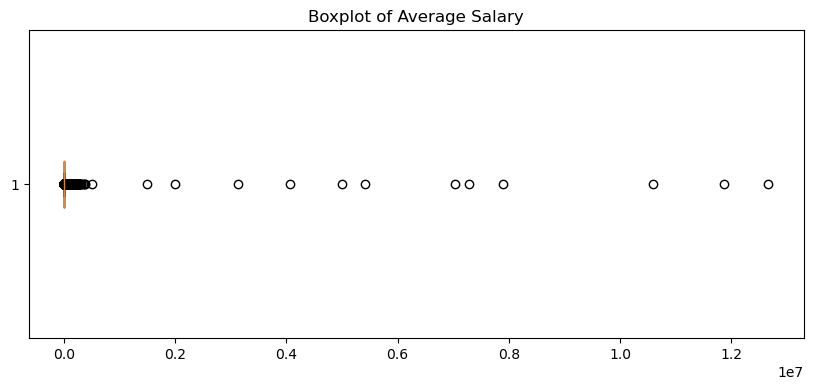

In [142]:
#Salary Distribution (Outliers)
plt.figure(figsize=(10,4))

plt.boxplot(df['average_salary'].dropna(), vert=False)

plt.title("Boxplot of Average Salary")

plt.show()

#Questions to ask

#1. Are there any extremely high salaries?
#2.Are they genuine executive roles?
#3 are there any data entry errors?

3.4.2 Vacancy Validation

Negative: 0
Zero: 3988


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
197478,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
197480,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
197485,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
197488,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
197502,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0


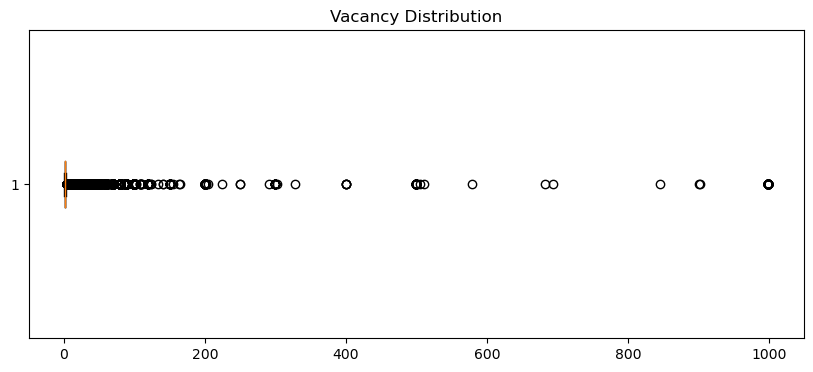

In [143]:
# Negative vacancies
negative_vacancies = df[df['numberOfVacancies'] < 0]

# Zero vacancies
zero_vacancies = df[df['numberOfVacancies'] == 0]

print("Negative:", len(negative_vacancies))
print("Zero:", len(zero_vacancies))

display(zero_vacancies.head())

#box plot:
plt.figure(figsize=(10,4))

plt.boxplot(df['numberOfVacancies'].dropna(), vert=False)

plt.title("Vacancy Distribution")

plt.show()

3.4.3 Experience Validation

In [144]:
# Negative experience
negative_exp = df[df['minimumYearsExperience'] < 0]

# Unrealistic experience
high_exp = df[df['minimumYearsExperience'] > 40]

print("Negative:", len(negative_exp))
print("Above 40 years:", len(high_exp))

display(high_exp)

Negative: 0
Above 40 years: 21


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
89073,"[{""id"":21,""category"":""Information Technology""}]",Contract,2023-06-09,False,MCF-2023-0115276,2023-05-10,2023-02-13,2,23,334,...,NaN,Manager,YAYASAN MENDAKI,6160,4400,Monthly,0,Closed,"Manager /Senior Manager, Digital Information T...",5280.0
125726,"[{""id"":8,""category"":""Customer Service""},{""id"":...",Permanent,2023-07-01,False,MCF-2023-0424191,2023-06-01,2023-06-01,0,4,102,...,NaN,Fresh/entry level,UEMS SOLUTIONS PTE. LTD.,1600,1400,Monthly,0,Open,Porter,1500.0
173585,"[{""id"":35,""category"":""Sales / Retail""}]",Permanent,2023-07-04,False,MCF-2023-0473510,2023-06-20,2023-06-20,0,10,77,...,NaN,Manager,DNV SINGAPORE PTE. LTD.,12000,6000,Monthly,0,Open,APAC Software Sales & Team management (Digital...,9000.0
193514,"[{""id"":1,""category"":""Accounting / Auditing / T...",Permanent,2023-07-12,False,MCF-2023-0449071,2023-06-12,2023-06-12,0,1,99,...,NaN,Fresh/entry level,PRICEWATERHOUSECOOPERS LLP,5000,3000,Monthly,0,Open,Financial Services Assurance Associate,4000.0
215375,"[{""id"":21,""category"":""Information Technology""}]",Full Time,2023-07-28,False,MCF-2023-0516291,2023-07-07,2023-07-07,0,1,5,...,NaN,Professional,KAYA TECH PTE. LTD.,15000,8000,Monthly,0,Open,Block Chain Senior Backend Engineer,11500.0
306092,"[{""id"":25,""category"":""Manufacturing""}]",Full Time,2023-09-07,False,MCF-2023-0605561,2023-08-08,2023-08-08,0,1,8,...,NaN,Manager,CIBA VISION ASIAN MANUFACTURING AND LOGISTICS ...,11000,10500,Monthly,0,Open,Regulatory Affairs Manager,10750.0
389983,"[{""id"":21,""category"":""Information Technology""}]",Contract,2023-10-08,False,MCF-2023-0688867,2023-09-08,2023-09-08,0,0,2,...,NaN,Professional,CENTRAL PROVIDENT FUND BOARD,11300,6000,Monthly,0,Open,Lead/ Senior Storage Engineer,8650.0
398461,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-09-26,False,MCF-2023-0698710,2023-09-12,2023-09-12,0,0,1,...,NaN,Manager,NEW AMEERAH FOOD CHAINS PTE. LTD.,5000,3000,Monthly,0,Open,STORE ASSISTANT,4000.0
438023,"[{""id"":1,""category"":""Accounting / Auditing / T...",Permanent,2023-10-26,False,MCF-2023-0735169,2023-09-26,2023-09-26,0,0,1,...,NaN,Fresh/entry level,PRICEWATERHOUSECOOPERS LLP,5000,3000,Monthly,0,Open,Financial Services Assurance Associate,4000.0
583890,"[{""id"":35,""category"":""Sales / Retail""}]",Full Time,2023-12-23,True,MCF-2023-0917340,2023-11-23,2023-11-23,0,0,2,...,NaN,Executive,51 EMPLOYMENT AGENCY PTE. LTD.,5000,3000,Monthly,0,Open,MANUFACTURER'S SALES REPRESENTATIVE,4000.0


3.4.4 Applications Validation

0


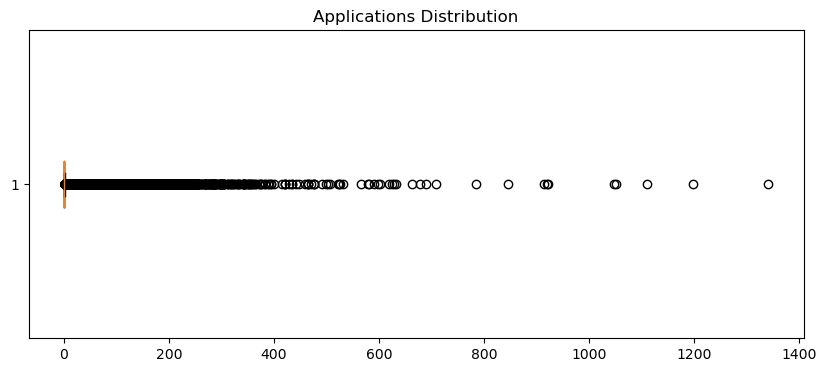

In [145]:
negative_apps = df[
    df['metadata_totalNumberJobApplication'] < 0
]

print(len(negative_apps))

plt.figure(figsize=(10,4))

plt.boxplot(
    df['metadata_totalNumberJobApplication'].dropna(),
    vert=False
)

plt.title("Applications Distribution")

plt.show()

3.4.5 Views Validation

In [146]:
negative_views = df[
    df['metadata_totalNumberOfView'] < 0
]

print(len(negative_views))

0


3.4.6 Repost Count Validation

In [147]:
negative_repost = df[
    df['metadata_repostCount'] < 0
]

print(len(negative_repost))

0


3.4.7 Date Validation

In [148]:
# Convert to datetime
date_columns = [
    'metadata_originalPostingDate',
    'metadata_newPostingDate',
    'metadata_expiryDate'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [149]:
# Check expiry date
invalid_dates = df[
    df['metadata_expiryDate']
    <
    df['metadata_originalPostingDate']
]

print("Invalid date records:", len(invalid_dates))

display(invalid_dates)

Invalid date records: 0


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary


# 3.5 Categorical Data Validation ⭐

This section is very valuable.



In [150]:
#Employment Type check for standard names- or any repeat name issues    
df['employmentTypes'].value_counts(dropna=False)

Permanent                458139
Full Time                393352
Contract                 139182
Part Time                 25431
Temporary                 18241
Internship/Attachment      6959
NaN                        3988
Freelance                  2139
Flexi-work                 1154
Name: employmentTypes, dtype: int64

In [151]:
#Position Level,  Like: Senior Executive, Senior executive, Sr Executive
df['positionLevels'].value_counts(dropna=False)

Executive            253701
Junior Executive     167656
Non-executive        131608
Fresh/entry level    118661
Professional         112208
Manager              110122
Senior Executive     100459
Middle Management     27375
Senior Management     22807
NaN                    3988
Name: positionLevels, dtype: int64

In [152]:
# Company name:
df['postedCompany_name'].value_counts().head(20)

THE SUPREME HR ADVISORY PTE. LTD.    61638
RECRUITPEDIA PTE. LTD.               50444
RECRUIT EXPRESS PTE LTD              33170
ANRADUS PTE. LTD.                    25805
RECRUIT EXPERT PTE. LTD.             21608
PERSOLKELLY SINGAPORE PTE. LTD.      13153
TALENT TRADER GROUP PTE. LTD.         8429
RK RECRUITMENT PTE. LTD.              8178
RECRUIT LYNC PTE. LTD.                5901
HYPERSCAL SOLUTIONS PTE. LTD.         5874
ADECCO PERSONNEL PTE LTD              5639
TRUST RECRUIT PTE. LTD.               5490
RECRUITFLASH PTE. LTD.                5296
FLINTEX CONSULTING PTE. LTD.          5240
57 EMPLOYMENT AGENCY PTE. LTD.        5172
EA RECRUITMENT PTE. LTD.              5069
SEARCH PERSONNEL PRIVATE LIMITED      4820
RANDSTAD PTE. LIMITED                 4816
MINDFLEX EDUCATION PTE. LTD.          4598
MTC CONSULTING PTE. LTD.              3954
Name: postedCompany_name, dtype: int64

In [153]:
# Categories: Since categories is stored as JSON, first extract the primary category:
import json

def extract_category(x):
    try:
        data = json.loads(x)
        return data[0]['category'] if len(data) > 0 else "Unknown"
    except:
        return "Unknown"

df['Industry'] = df['categories'].apply(extract_category)

#to inspect:

df['Industry'].value_counts().head(20)

Admin / Secretarial                 102719
Information Technology              100142
Engineering                          99675
Accounting / Auditing / Taxation     78648
Building and Construction            74014
Customer Service                     64865
F&B                                  59678
Banking and Finance                  46635
Logistics / Supply Chain             44391
Sales / Retail                       37313
Education and Training               35611
Healthcare / Pharmaceutical          33229
Others                               24758
Consulting                           24187
Marketing / Public Relations         23275
Human Resources                      23062
Advertising / Media                  17233
Manufacturing                        16352
Architecture / Interior Design       14663
General Work                         14647
Name: Industry, dtype: int64

In [154]:
#Job Titles check for standard names- or any repeat name issues
df['title'].sample(20)


## Check for: Leading or trailing spaces, ALL CAPS title, Mixed capitalisati, unnecessary punctuations)

df['title'] = (
    df['title']
    .str.strip()
    .str.title()
)

# 4. Data Cleaning

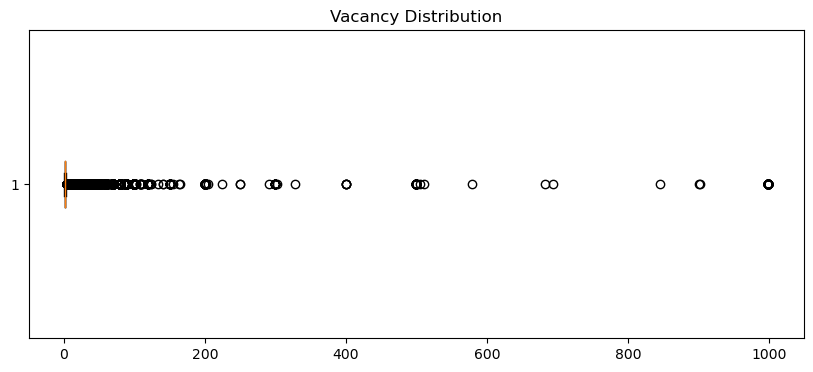

In [155]:

plt.figure(figsize=(10,4))

plt.boxplot(df['numberOfVacancies'].dropna(), vert=False)

plt.title("Vacancy Distribution")

plt.show()# Numeric Imputation
df['salary_minimum']=df['salary_minimum'].fillna(df['salary_minimum'].median())
df['salary_maximum']=df['salary_maximum'].fillna(df['salary_maximum'].median())

# Recalculate Average Salary
df['average_salary']=(df['salary_minimum']+df['salary_maximum'])/2

# Experience
df['minimumYearsExperience']=df['minimumYearsExperience'].fillna(df['minimumYearsExperience'].median())

# Categorical
df['positionLevels']=df['positionLevels'].fillna('Unknown')
df['employmentTypes']=df['employmentTypes'].fillna('Unknown')


In [156]:
# Find numeric columns where every value is 0
all_zero_cols = []

for col in df.select_dtypes(include=['number']).columns:
    if (df[col] == 0).all():
        all_zero_cols.append(col)

print("Columns with all zero values:")
print(all_zero_cols)

Columns with all zero values:
['status_id']


In [157]:
# Count missing values in each column
missing_count = df.isnull().sum()

# Keep only columns with missing values
missing_count = missing_count[missing_count > 0]

print(missing_count)

categories                         3988
metadata_expiryDate                3988
metadata_jobPostId                 3988
metadata_newPostingDate            3988
metadata_originalPostingDate       3988
occupationId                    1048585
postedCompany_name                 3988
salary_type                        3988
status_jobStatus                   3988
title                              3988
dtype: int64


## Data Cleaning for 0 values or NaN, OR Missing values 
#### Observation 1: Column with all zero
##### To drop column "status_id" as that is 0 for all rows and has no analytical significance 

In [158]:
#To drop status id_ as that is 0 for all rows and has no analytical significance 
if 'status_id' in df.columns:
    df.drop(columns=['status_id'], inplace=True)
else:
    print("Column 'status_id' already dropped or does not exist")

#### Observation 2: occupationId is 100% missing

In [159]:
# this is 100% missing values, and has no significance for biz decisions / analysis
if 'occupationId' in df.columns:
    df.drop(columns=['occupationId'], inplace=True)
else:
    print("Column 'occupationId' not found; it may already have been dropped.")

#### Observation 3: ApplicationRate has 17.46% missing
if undefined, so the result becomes NaN.
Do NOT simply replace these NaNs with 0. Instead, investigate why they are missing.

In [160]:
df[df['ApplicationRate'].isna()][
    ['metadata_totalNumberOfView',
     'metadata_totalNumberJobApplication']
].head()

KeyError: 'ApplicationRate'

##### Missing values occur because some job postings recorded zero views. Since an application rate cannot be calculated when the denominator is zero, these missing values were replaced with 0 for dashboard consistency.

#### Observation 4: About 3,988 missing values (0.38%) in several columns

These columns include:

categories;
title;
postedCompany_name;
salary_type;
metadata_originalPostingDate;
metadata_newPostingDate;
metadata_expiryDate;
status_jobStatus;
metadata_jobPostId.

##### Since all of them have exactly 3,988 missing values, they likely belong to the same records.
If those rows are almost completely empty==>Then it is reasonable to remove them.


In [ ]:
missing_rows = df[df['categories'].isnull()]

print(missing_rows.shape)
missing_rows.head()
missing_rows.isnull().sum()

(3988, 21)


categories                            3988
employmentTypes                          0
metadata_expiryDate                   3988
metadata_isPostedOnBehalf                0
metadata_jobPostId                    3988
metadata_newPostingDate               3988
metadata_originalPostingDate          3988
metadata_repostCount                     0
metadata_totalNumberJobApplication       0
metadata_totalNumberOfView               0
minimumYearsExperience                   0
numberOfVacancies                        0
positionLevels                           0
postedCompany_name                    3988
salary_maximum                           0
salary_minimum                           0
salary_type                           3988
status_jobStatus                      3988
title                                 3988
average_salary                           0
Industry                                 0
dtype: int64

In [ ]:
df.shape

(1048585, 21)

In [ ]:
df = df.dropna(
    subset=[
        'categories',
        'title',
        'postedCompany_name',
        'metadata_originalPostingDate'
    ]
)

#It deletes rows where any of these columns contain a missing (NaN) value.

In [ ]:
df.shape

(1048585, 21)

In [ ]:
# Create missing value summary
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})

# Show only columns with missing values
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

# Sort by highest missing percentage
missing_summary = missing_summary.sort_values(by='Missing %', ascending=False)

missing_summary

,Missing Count,Missing %
categories,3988,0.380322
metadata_expiryDate,3988,0.380322
metadata_jobPostId,3988,0.380322
metadata_newPostingDate,3988,0.380322
metadata_originalPostingDate,3988,0.380322
postedCompany_name,3988,0.380322
salary_type,3988,0.380322
status_jobStatus,3988,0.380322
title,3988,0.380322


In [ ]:
df.shape

(1048585, 21)

# 5. Feature Engineering

Create additional features from the existing dataset to support
exploratory analysis and dashboard development.

These features simplify time-series analysis and provide additional
business metrics for measuring hiring competition.

will be useful later.

In [ ]:
import numpy as np

# ---------------------------------------------------
# Feature Engineering
# ---------------------------------------------------

# Ensure posting date is datetime
df["metadata_originalPostingDate"] = pd.to_datetime(
    df["metadata_originalPostingDate"],
    errors="coerce"
)

# Date Features
df["PostingYear"] = df["metadata_originalPostingDate"].dt.year

df["PostingMonth"] = df["metadata_originalPostingDate"].dt.month_name()

df["PostingQuarter"] = (
    "Q" +
    df["metadata_originalPostingDate"].dt.quarter.astype(str)
)

# Competition Index
df["CompetitionIndex"] = np.where(
    df["numberOfVacancies"] > 0,
    df["metadata_totalNumberJobApplication"] /
    df["numberOfVacancies"],
    np.nan
)

# Application Rate
df["ApplicationRate"] = np.where(
    df["metadata_totalNumberOfView"] > 0,
    df["metadata_totalNumberJobApplication"] /
    df["metadata_totalNumberOfView"],
    np.nan
)

In [ ]:
df.shape

(1048585, 26)

In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nNew Features:")
feature_cols = [
    "PostingYear",
    "PostingMonth",
    "PostingQuarter",
    "CompetitionIndex",
    "ApplicationRate",
]

# Ensure the engineered features exist before using them
if "metadata_originalPostingDate" in df.columns:
    df["metadata_originalPostingDate"] = pd.to_datetime(
        df["metadata_originalPostingDate"],
        errors="coerce"
    )

if "PostingYear" not in df.columns:
    df["PostingYear"] = df["metadata_originalPostingDate"].dt.year

if "PostingMonth" not in df.columns:
    df["PostingMonth"] = df["metadata_originalPostingDate"].dt.month_name()

if "PostingQuarter" not in df.columns:
    df["PostingQuarter"] = "Q" + df["metadata_originalPostingDate"].dt.quarter.astype(str)

if "CompetitionIndex" not in df.columns:
    df["CompetitionIndex"] = np.where(
        df["numberOfVacancies"] > 0,
        df["metadata_totalNumberJobApplication"] / df["numberOfVacancies"],
        np.nan
    )

if "ApplicationRate" not in df.columns:
    df["ApplicationRate"] = np.where(
        df["metadata_totalNumberOfView"] > 0,
        df["metadata_totalNumberJobApplication"] / df["metadata_totalNumberOfView"],
        np.nan
    )

print(df[feature_cols].head())

print("\nMissing Values")
print(
    df[[
        "PostingYear",
        "PostingMonth",
        "PostingQuarter",
        "CompetitionIndex",
        "ApplicationRate"
    ]].isnull().sum()
)

#confirmation that the engineered features were created correctly 

Dataset Shape:
(1048585, 26)

New Features:
   PostingYear PostingMonth PostingQuarter  CompetitionIndex  ApplicationRate
0       2023.0        March           Q1.0               5.0         0.033113
1       2023.0        April           Q2.0               0.0         0.000000
2       2023.0        April           Q2.0               7.0         0.070707
3       2023.0        April           Q2.0               6.0         0.053097
4       2023.0        April           Q2.0               1.0         0.030303

Missing Values
PostingYear           3988
PostingMonth          3988
PostingQuarter           0
CompetitionIndex      3988
ApplicationRate     183109
dtype: int64


### Why Create These Features?

|Feature|Business Value|
|---|---|
|Posting Year|Trend analysis|
|Posting Month|Seasonality|
|Competition Index|Measure applicant competition|
|Application Rate|Measure posting attractiveness|


# 6. Final Validation

Before moving to EDA:

- Confirm missing values have been addressed appropriately.
- Validate data types.
- Check engineered features.
- Save the cleaned dataset.


In [ ]:
df.info()

df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048585 entries, 0 to 1048584
Data columns (total 26 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   categories                          1044597 non-null  object        
 1   employmentTypes                     1048585 non-null  object        
 2   metadata_expiryDate                 1044597 non-null  datetime64[ns]
 3   metadata_isPostedOnBehalf           1048585 non-null  bool          
 4   metadata_jobPostId                  1044597 non-null  object        
 5   metadata_newPostingDate             1044597 non-null  datetime64[ns]
 6   metadata_originalPostingDate        1044597 non-null  datetime64[ns]
 7   metadata_repostCount                1048585 non-null  int64         
 8   metadata_totalNumberJobApplication  1048585 non-null  int64         
 9   metadata_totalNumberOfView          1048585 non-null  int64         

/tmp/ipykernel_47337/328117025.py:3: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df.describe(include='all')
/tmp/ipykernel_47337/328117025.py:3: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df.describe(include='all')
/tmp/ipykernel_47337/328117025.py:3: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df.describe(include='all')


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,salary_type,status_jobStatus,title,average_salary,Industry,PostingYear,PostingMonth,PostingQuarter,CompetitionIndex,ApplicationRate
count,1044597,1048585,1044597,1048585,1044597,1044597,1044597,1.048585e+06,1.048585e+06,1.048585e+06,...,1044597,1044597,1044597,1.048585e+06,1048585,1.044597e+06,1044597,1048585,1.044597e+06,865476.000000
unique,21125,9,453,2,1044597,431,603,NaN,NaN,NaN,...,1,3,365602,NaN,44,NaN,12,5,NaN,NaN
top,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-07-28 00:00:00,False,RANDOM_JOB_20251115011349636339_9,2023-06-09 00:00:00,2023-07-14 00:00:00,NaN,NaN,NaN,...,Monthly,Open,Supervisor,NaN,Admin / Secretarial,NaN,May,Q2.0,NaN,NaN
freq,92869,458139,4487,986717,1,4508,4029,NaN,NaN,NaN,...,1044597,902614,13005,NaN,102719,NaN,143344,328490,NaN,NaN
first,NaN,NaN,2023-04-04 00:00:00,NaN,NaN,2023-02-24 00:00:00,2022-10-03 00:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,NaN,NaN,2024-12-12 00:00:00,NaN,NaN,2024-05-29 00:00:00,2024-05-29 00:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.472327e-02,2.136571e+00,2.674536e+01,...,NaN,NaN,NaN,4.769445e+03,NaN,2.023366e+03,NaN,NaN,1.665546e+00,0.057456
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.822675e-01,1.062612e+01,8.262001e+01,...,NaN,NaN,NaN,2.547809e+04,NaN,4.855446e-01,NaN,NaN,8.795613e+00,0.114119
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,...,NaN,NaN,NaN,0.000000e+00,NaN,2.022000e+03,NaN,NaN,0.000000e+00,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,1.000000e+00,...,NaN,NaN,NaN,2.900000e+03,NaN,2.023000e+03,NaN,NaN,0.000000e+00,0.000000


In [ ]:
validation = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2)
})

validation = validation[validation["Missing"] > 0]
validation.sort_values("Missing", ascending=False)

,Missing,Missing %
ApplicationRate,183109,17.46
metadata_expiryDate,3988,0.38
metadata_jobPostId,3988,0.38
metadata_newPostingDate,3988,0.38
categories,3988,0.38
metadata_originalPostingDate,3988,0.38
postedCompany_name,3988,0.38
status_jobStatus,3988,0.38
salary_type,3988,0.38
title,3988,0.38


## Final Data Quality Summary

The dataset has been successfully cleaned and validated.

The remaining missing values are expected and have been retained because
they cannot be reliably imputed without introducing inaccurate information.

The cleaned dataset is now ready for Exploratory Data Analysis (Part 02).

In [ ]:
print("=" * 50)
print("Final Data Quality Summary")
print("=" * 50)

print(f"Rows              : {df.shape[0]:,}")
print(f"Columns           : {df.shape[1]}")
print(f"Duplicate Rows    : {df.duplicated().sum()}")

print("\nRemaining Missing Values")
display(validation.sort_values("Missing", ascending=False))

Final Data Quality Summary
Rows              : 1,048,585
Columns           : 26
Duplicate Rows    : 3987

Remaining Missing Values


,Missing,Missing %
ApplicationRate,183109,17.46
metadata_expiryDate,3988,0.38
metadata_jobPostId,3988,0.38
metadata_newPostingDate,3988,0.38
categories,3988,0.38
metadata_originalPostingDate,3988,0.38
postedCompany_name,3988,0.38
status_jobStatus,3988,0.38
salary_type,3988,0.38
title,3988,0.38


In [ ]:
# Save cleaned dataset
df.to_csv('SGJobs_Cleaned_01.csv',index=False)

print("Cleaned dataset saved successfully")




Cleaned dataset saved successfully


In [ ]:
df.shape

(1048585, 26)

In [ ]:
df.columns.tolist()

['categories',
 'employmentTypes',
 'metadata_expiryDate',
 'metadata_isPostedOnBehalf',
 'metadata_jobPostId',
 'metadata_newPostingDate',
 'metadata_originalPostingDate',
 'metadata_repostCount',
 'metadata_totalNumberJobApplication',
 'metadata_totalNumberOfView',
 'minimumYearsExperience',
 'numberOfVacancies',
 'positionLevels',
 'postedCompany_name',
 'salary_maximum',
 'salary_minimum',
 'salary_type',
 'status_jobStatus',
 'title',
 'average_salary',
 'Industry',
 'PostingYear',
 'PostingMonth',
 'PostingQuarter',
 'CompetitionIndex',
 'ApplicationRate']

In [ ]:
df[[
    "PostingYear",
    "PostingMonth",
    "PostingQuarter",
    "CompetitionIndex",
    "ApplicationRate"
]].isnull().sum()

PostingYear           3988
PostingMonth          3988
PostingQuarter           0
CompetitionIndex      3988
ApplicationRate     183109
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048585 entries, 0 to 1048584
Data columns (total 26 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   categories                          1044597 non-null  object        
 1   employmentTypes                     1048585 non-null  object        
 2   metadata_expiryDate                 1044597 non-null  datetime64[ns]
 3   metadata_isPostedOnBehalf           1048585 non-null  bool          
 4   metadata_jobPostId                  1044597 non-null  object        
 5   metadata_newPostingDate             1044597 non-null  datetime64[ns]
 6   metadata_originalPostingDate        1044597 non-null  datetime64[ns]
 7   metadata_repostCount                1048585 non-null  int64         
 8   metadata_totalNumberJobApplication  1048585 non-null  int64         
 9   metadata_totalNumberOfView          1048585 non-null  int64         

In [ ]:
print("Jobs with zero vacancies:")
print((df["numberOfVacancies"] == 0).sum())

print("\nJobs with zero views:")
print((df["metadata_totalNumberOfView"] == 0).sum())

Jobs with zero vacancies:
3988

Jobs with zero views:
183109


In [ ]:
validation = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2)
})




,Missing,Missing %
ApplicationRate,183109,17.46
metadata_expiryDate,3988,0.38
metadata_jobPostId,3988,0.38
metadata_newPostingDate,3988,0.38
categories,3988,0.38
metadata_originalPostingDate,3988,0.38
postedCompany_name,3988,0.38
status_jobStatus,3988,0.38
salary_type,3988,0.38
title,3988,0.38


### Remaining Missing Values

Although missing values remain in the cleaned dataset, they were intentionally retained because they cannot be reliably imputed without introducing inaccurate information.

| Column                       | Reason for Missing Values               | Action Taken        |
| ---------------------------- | --------------------------------------- | ------------------- |
| metadata_originalPostingDate | Original source data missing            | Retained as missing |
| PostingYear                  | Derived from missing posting date       | Retained as missing |
| PostingMonth                 | Derived from missing posting date       | Retained as missing |
| CompetitionIndex             | Cannot be calculated when vacancies = 0 | Retained as missing |
| ApplicationRate              | Cannot be calculated when views = 0     | Retained as missing |


| Column                         | Why not impute?                                                                      |
| ------------------------------ | ------------------------------------------------------------------------------------ |
| `metadata_originalPostingDate` | Original value is unknown; imputing would create inaccurate time-series analysis.    |
| `PostingYear`                  | Derived from the missing posting date, so it must remain missing.                    |
| `PostingMonth`                 | Derived from the missing posting date, so it must remain missing.                    |
| `ApplicationRate`              | Cannot be calculated when the number of views is zero.                               |
| `CompetitionIndex`             | Cannot be calculated when vacancies are zero (or if the denominator is unavailable). |

 This preserves data integrity and avoids introducing artificial values that could bias subsequent analyses.

## Final Dataset Summary

The cleaned dataset has now been:

- Validated
- Cleaned
- Enhanced through feature engineering
- Saved for downstream analysis

This dataset will be used in Part 02 (EDA) and the Streamlit dashboard.

# Summary

In this notebook we have :

- Defined the business problem.
- Understood the dataset.
- Assessed data quality.
- Evaluated missing values.
- Applied appropriate cleaning methods.
- Created new analytical features.

The cleaned dataset is now ready for **Part 2 – Exploratory Data Analysis (EDA)** where we will answer the business questions through visualisations and insights.
